In [197]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# Core machine learning and image processing libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Visualization library for accuracy curves
import matplotlib.pyplot as plt
# System library for file path management
import os
import numpy as np
# Environment verification
print("Python Version: 3.13.2")
print("TensorFlow Version:", tf.__version__)

# Fixed parameters according to project requirements
IMAGE_SIZE = (240, 240)    # Required image resolution
BATCH_SIZE = 8           # Batch size for training
NUM_CLASSES = 3            # 3 shoe brands: Nike, Adidas, Converse
EPOCHS = 20                # Training iterations

# Dataset paths
TRAIN_PATH = "C:\\Users\\manfr\\Desktop\\School\\MetroU\\Year 3 Second half\\COMP 3920SEF Machine Learning\\Mini Project\\train"
VAL_PATH = "C:\\Users\\manfr\\Desktop\\School\\MetroU\\Year 3 Second half\\COMP 3920SEF Machine Learning\\Mini Project\\validate"

# Model save path (required for submission)
MODEL_PATH = "shoe_classifier.h5"

Python Version: 3.13.2
TensorFlow Version: 2.21.0


In [2]:
# Training data: shoe-specific data augmentation (protect logo/shape features)
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    horizontal_flip=True,
    rotation_range=8,
    zoom_range=[0.9, 1.1],
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.88, 1.12],
    shear_range=0.05,
    fill_mode='nearest'
)

# Validation data: only normalization (no augmentation)
val_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Load training dataset from folder
train_data = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

# Load validation dataset from folder
val_data = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Print dataset information (verify loading success)
print("\nDataset Information:")
print(f"Training samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Class Labels: {train_data.class_indices}")

Found 603 images belonging to 3 classes.
Found 90 images belonging to 3 classes.

Dataset Information:
Training samples: 603
Validation samples: 90
Class Labels: {'adidas': 0, 'converse': 1, 'nike': 2}


C:\Users\manfr\AppData\Local\Temp\ipykernel_17392\1032279095.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
===== Stage 1: Train Classification Head =====
Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 13s 131ms/step - accuracy: 0.5738 - loss: 0.9576 - val_accuracy: 0.7111 - val_loss: 0.7052 - learning_rate: 0.0010
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.7529 - loss: 0.6018 - val_accuracy: 0.7000 - val_loss: 0.6646 - learning_rate: 0.0010
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.7678 - loss: 0.5075 - val_accuracy: 0.7778 - val_loss: 0.5244 - learning_rate: 0.0010
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.7977 - loss: 0.4860 - val_accuracy: 0.8000 - val_loss: 0.5722 - learning_rate: 0.0010
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.8640 - loss: 0.3764 - val_accuracy: 0.7111 - val_loss: 0.6098 - learning_rate: 0.0010
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - accuracy: 0.8922 - loss: 0.3166 - val_accuracy: 0.7444 - val_loss: 0.5453 - learning_rat

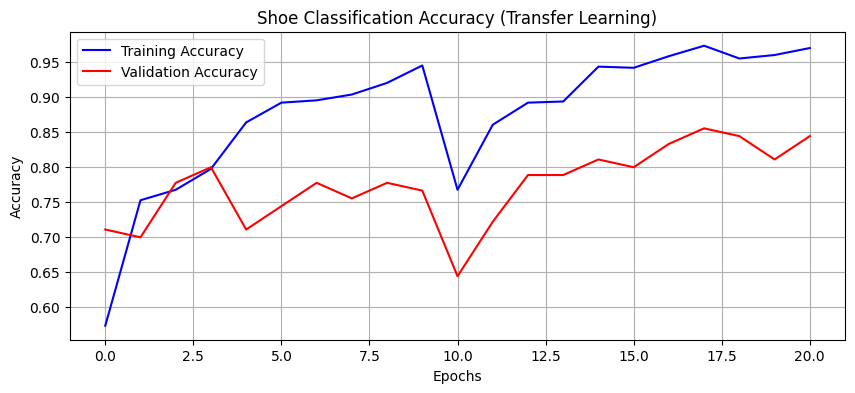


Model saved to: shoe_classifier.h5
Final Validation Accuracy: 84.44%


In [3]:
# %% Model Training
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

# ===================== 1. Build Transfer Learning Model =====================
# Load pre-trained MobileNetV2 (freeze base layers)
base_model = MobileNetV2(
    input_shape=(240, 240, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base model, only train top layers

# Build shoe classification model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),  # Replace Flatten to reduce overfitting
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
])

# ===================== 2. Define Callback Functions =====================
# Early stopping (prevent overfitting, keep best weights)
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Learning rate reduction (adapt learning rate dynamically)
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.6,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# ===================== 3. Stage 1: Train Classification Head =====================
print("===== Stage 1: Train Classification Head =====")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train top layers
history_stage1 = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ===================== 4. Stage 2: Fine-tune Pre-trained Model =====================
print("\n===== Stage 2: Fine-tune Model =====")
# Unfreeze last 20 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_stage2 = model.fit(
    train_data,
    epochs=20,
    initial_epoch=history_stage1.epoch[-1],
    validation_data=val_data,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ===================== 5. Visualize Training Results =====================
# Merge history from two stages
acc = history_stage1.history['accuracy'] + history_stage2.history['accuracy']
val_acc = history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
epochs_range = range(len(acc))

# Plot accuracy curve
plt.figure(figsize=(10, 4))
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red')
plt.title('Shoe Classification Accuracy (Transfer Learning)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# ===================== 6. Save Trained Model =====================
model.save(MODEL_PATH)
print(f"\nModel saved to: {MODEL_PATH}")
print(f"Final Validation Accuracy: {round(val_acc[-1], 4) * 100}%")

In [4]:
# Load Model & Validation Set Test
# Load the saved model
loaded_model = load_model(MODEL_PATH)
print("Model loaded successfully!")

# Reset validation data generator (critical for consistent evaluation)
val_data.reset()

# Evaluate model on validation dataset
val_loss, val_accuracy = loaded_model.evaluate(val_data, verbose=1)

# Print final results
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Pass grade check (Accuracy ≥ 50%)
if val_accuracy >= 0.5:
    print("✅ PASS: Validation accuracy meets the requirement (≥50%)")
else:
    print("❌ FAIL: Please adjust the model to improve accuracy")

Model loaded successfully!
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.8556 - loss: 0.7174

Validation Loss: 0.7174
Validation Accuracy: 0.8556
✅ PASS: Validation accuracy meets the requirement (≥50%)
